# 1. Definición del Problema y Enfoque Analítico

Habiendo concluido exitosamente la fase de modelado supervisado, donde entrenamos una Red Neuronal Multicapa capaz de anticipar la probabilidad de deterioro de un crédito, en este notebook cambiaremos nuestro paradigma analítico. Abordaremos el aprendizaje no supervisado mediante técnicas de agrupamiento (*Clustering*).

En el contexto del riesgo crediticio, el aprendizaje no supervisado no busca predecir una etiqueta o variable objetivo conocida, sino descubrir la estructura intrínseca y los patrones ocultos que residen de forma natural en los datos. Sin embargo, aplicar un algoritmo de agrupamiento sobre el millón de registros de nuestra cartera total representaría un esfuerzo computacional ineficiente y con poco valor de negocio. Matemáticamente, debido a nuestro fuerte desbalance de clases, el algoritmo probablemente se limitaría a recrear la frontera entre clientes "sanos" y "riesgosos" (algo que ya hace nuestra normativa NIFBdM C-16) o, en el peor de los casos, sus centroides serían absorbidos por el 81% de los créditos correspondientes a la Etapa 1.

## 1.1. Enfoque estratégico: Perfiles de Morosidad
Para que este análisis complemente e integre nuestros hallazgos predictivos, tomaremos una decisión de diseño: aislaremos y analizaremos exclusivamente a la **Cartera Vencida (Etapa 3)**.

Nuestra hipótesis analítica es que el incumplimiento hipotecario no es un comportamiento aislado. Los acreditados caen en impago por diferentes conjuntos de razones demográficas, socioeconómicas y estructurales del crédito. Al agrupar únicamente a los cohortes que ya han materializado el riesgo (Etapa 3), obligaremos al algoritmo a responder una pregunta valiosa para el negocio: **¿Cuáles son los distintos perfiles de clientes que caen en mora (cartera vencida o riesgo de crédito alto)?**

Descubrir estos grupos ocultos (por ejemplo, diferenciar entre un "Acreditado joven sobreendeudado por créditos" y un "Acreditado adulto mayor con propiedades residenciales de alto valor") le permite a la institución financiera tomar decisiones estratégicas avanzadas, como diseñar campañas de cobranza especializadas, ofrecer planes de reestructuración de deuda a la medida del perfil, o endurecer los filtros de aprobación específicos para los nichos más vulnerables.

Para lograr este objetivo, nos enfrentaremos a un desafío técnico particular: nuestro vector de características es mixta: contiene variables numéricas continuas (como el saldo insoluto) con variables categóricas nominales y ordinales. En los siguientes capítulos, estableceremos una estrategia rigurosa de submuestreo, eligiendo métricas de distancia especializadas y algoritmos robustos ante valores atípicos que nos permitan medir con fidelidad la similitud entre estos créditos deteriorados.

# 2. Selección y Preprocesamiento de Datos
Para garantizar el éxito de nuestro análisis de agrupamiento, debemos preparar el entorno de datos. A diferencia de los modelos supervisados, donde las transformaciones buscan optimizar el cálculo de gradientes y prevenir el sobreajuste, en el aprendizaje no supervisado el objetivo del preprocesamiento es asegurar que el cálculo de similitudes (distancias) entre dos observaciones sea matemáticamente adecuado.

## 2.1. Filtrado y Muestreo Aleatorio
De acuerdo con nuestra definición del problema, el primer paso es filtrar nuestro dataset original para conservar únicamente los cohortes clasificados en la Etapa 3. En nuestra muestra de un millón de registros, esto nos deja con aproximadamente 80,000 observaciones de cartera vencida.

Aunque 80,000 registros es un volumen excelente para entrenar redes neuronales, representa un obstáculo técnico para los algoritmos de agrupamiento basados en medoides. El algoritmo PAM (Partitioning Around Medoids) requiere la construcción de una matriz de distancias que cruza a todos los individuos contra todos. Para 80,000 créditos, esto implica calcular más de 3,200 millones de distancias cruzadas, requiriendo un alto costo de memoria RAM para alojar la matriz.

Para resolver esto, extraeremos una muestra aleatoria representativa de 10,000 registros. Dado que ya hemos aislado una población homogénea en términos de nivel de riesgo (todos son Etapa 3), un muestreo aleatorio simple es suficiente para capturar la varianza de los perfiles de incumplimiento.

## 2.2. Selección de Variables
El agrupamiento es altamente sensible al "ruido" y a la maldición de la dimensionalidad. Incluir variables irrelevantes o constantes diluye la noción de distancia, haciendo que todos los clientes parezcan equidistantes. Por ello, eliminaremos la variable `etapa`, que ahora se convierto una constante (ya que solo nos centramos en los valores de Etapa 3) y conservaremos las 9 dimensiones restantes de nuestro EDA. 

Estas dimensiones nos permitirán construir los perfiles de morosidad:
* **Variables demográficas:** `intervalo_edades`, `intervalo_ingreso_acreditado`, `sector_laboral`.
* **Variables del producto:** `estado`, `destino_credito`, `segmento_vivienda`, `moneda`.
* **Variables financieras:** `saldo_insoluto_final_periodo`, `tasa_ponderada`.

## 2.3. Tratamiento de Datos Mixtos
Para el cálculo de distancias necesario para el agrupamiento, la decisión de utilizar la **Distancia de Gower**. Esta métrica está diseñada matemáticamente para calcular la similitud en conjuntos de datos mixtos de forma nativa. Para las variables cuantitativas (saldo y tasa), Gower calcula la diferencia absoluta estandarizada por el rango de la variable. Para las categóricas, aplica un coeficiente de coincidencia simple (1 si son iguales, 0 si son diferentes).

Por lo tanto, la única transformación necesaria en este punto será asegurar que nuestra estructura de datos (DataFrame) asigne el tipo de dato correcto a cada columna: variables numéricas puras como punto flotante (`float64`) y variables cualitativas como categorías (`category`).

In [1]:
import pandas as pd
import numpy as np

print("=" * 60)
print("SELECCIÓN Y PREPARACIÓN DE DATOS PARA CLUSTERING")
print("=" * 60)

# 1. Carga del dataset limpio proveniente del EDA
ruta_archivo = '../data/Datos_Procesados/dataset_hipotecario_limpio.csv'
df = pd.read_csv(ruta_archivo)

# 2. Filtrado: Aislamiento exclusivo de la Cartera Vencida (Etapa 3)
df_etapa3 = df[df['etapa'] == 'Etapa 3'].copy()
total_etapa3 = df_etapa3.shape[0]
print(f"Total de registros en Etapa 3 identificados: {total_etapa3:,}")

# 3. Muestreo representativo para viabilidad computacional (Matriz de Distancias)
# Utilizamos random_state para garantizar que la ejecución sea reproducible
MUESTRA_TAMANO = 10000

if total_etapa3 > MUESTRA_TAMANO:
    df_muestra_cluster = df_etapa3.sample(n=MUESTRA_TAMANO, random_state=42)
else:
    df_muestra_cluster = df_etapa3

print(f"Tamaño de la muestra extraída para PAM: {df_muestra_cluster.shape[0]:,} registros\n")

# 4. Selección de Variables y Eliminación de constantes
# La columna 'etapa' ya no aporta varianza, la eliminamos
df_muestra_cluster = df_muestra_cluster.drop(columns=['etapa'])

# 5. Configuración de Tipos de Datos (Crucial para la métrica de Gower)
vars_numericas = ['saldo_insoluto_final_periodo', 'tasa_ponderada']
vars_categoricas = [
    'intervalo_edades', 'intervalo_ingreso_acreditado', 'sector_laboral', 
    'estado', 'destino_credito', 'segmento_vivienda', 'moneda'
]

# Forzamos los tipos correctos para evitar ambigüedades en el cálculo de distancias
for col in vars_numericas:
    df_muestra_cluster[col] = df_muestra_cluster[col].astype('float64')

for col in vars_categoricas:
    df_muestra_cluster[col] = df_muestra_cluster[col].astype('category')

print("=" * 60)
print("VISTA PREVIA DEL VECTOR DE CARACTERÍSTICAS MIXTO")
print("=" * 60)
print(df_muestra_cluster.info())
print("\nPrimeras observaciones:")
display(df_muestra_cluster.head())

SELECCIÓN Y PREPARACIÓN DE DATOS PARA CLUSTERING
Total de registros en Etapa 3 identificados: 80,285
Tamaño de la muestra extraída para PAM: 10,000 registros

VISTA PREVIA DEL VECTOR DE CARACTERÍSTICAS MIXTO
<class 'pandas.DataFrame'>
Index: 10000 entries, 522057 to 221445
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   intervalo_edades              10000 non-null  category
 1   intervalo_ingreso_acreditado  10000 non-null  category
 2   sector_laboral                10000 non-null  category
 3   estado                        10000 non-null  category
 4   destino_credito               10000 non-null  category
 5   segmento_vivienda             10000 non-null  category
 6   moneda                        10000 non-null  category
 7   saldo_insoluto_final_periodo  10000 non-null  float64 
 8   tasa_ponderada                10000 non-null  float64 
dtypes: category(7), float64(2)
me

,intervalo_edades,intervalo_ingreso_acreditado,sector_laboral,estado,destino_credito,segmento_vivienda,moneda,saldo_insoluto_final_periodo,tasa_ponderada
522057,46-55,"(40,001 - 80,000)",Sector privado,QUERÉTARO,Pago de Pasivos Hipotecarios,Media o Residencial,Moneda Nacional (Pesos),591767.47,13.00
279558,36-45,"(20,001 - 40,000)",Sector privado,SAN LUIS POTOSÍ,Adquisición de Vivienda Nueva,Media o Residencial,VSMG (Veces Salario Mínimo General),631273.22,9.03
423861,56-65,"(40,001 - 80,000)",Sector privado,CIUDAD DE MÉXICO,Pago de Pasivos Hipotecarios,Media o Residencial,Moneda Nacional (Pesos),141285.32,8.49
89496,36-45,"Más de 150,000 MXN",Sector público estatal,JALISCO,Adquisición de Vivienda Nueva,Media o Residencial,Moneda Nacional (Pesos),7193766.52,10.60
464161,36-45,"(20,001 - 40,000)",Sector privado,JALISCO,Adquisición de Vivienda Nueva,Media o Residencial,Moneda Nacional (Pesos),17017319.85,9.57


# 3. Estrategia de Agrupamiento: PAM y Distancia de Gower
Una vez definida nuestra muestra de 10,000 registros de la cartera vencida, el siguiente paso es seleccionar la métrica matemática para evaluar la "similitud" entre los clientes y el algoritmo que utilizará dicha métrica para conformar los grupos. Una medida de distancia errónea puede invalidar los resultados del algoritmo.

## 3.1. Justificación de la Métrica: Distancia de Gower
El estándar para medir similitud es la **Distancia Euclidiana**, definida como la longitud del segmento de recta que conecta dos puntos en un espacio Euclidiano: 
$$d(p, q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$$

Sin embargo, esta métrica asume estrictamente que todas las dimensiones son ortogonales y numéricas continuas. Nuestro vector de características es mixto. Como establecimos antes, para resolver este problema sin alterar la naturaleza de los datos, utilizaremos la **Distancia de Gower**. Esta métrica fue diseñada específicamente para calcular la proximidad en conjuntos de datos mixtos. Funciona calculando una similitud parcial para cada variable dependiendo de su tipo, y luego promediándolas.

Matemáticamente, la similitud de Gower $S_{ij}$ entre dos observaciones $i$ y $j$ se define como:
$$S_{ij} = \frac{\sum_{k=1}^{p} w_{ijk} s_{ijk}}{\sum_{k=1}^{p} w_{ijk}}$$

Donde para cada característica $k$:
* **Si $k$ es cuantitativa (ej. `saldo_insoluto_final_periodo`):** La similitud parcial es $s_{ijk} = 1 - \frac{|x_{ik} - x_{jk}|}{R_k}$, siendo $R_k$ el rango máximo observado de esa variable. Esto estandariza automáticamente el efecto de los montos millonarios.
* **Si $k$ es cualitativa nominal (ej. `estado`, `destino_credito`):** La similitud parcial es binaria: $s_{ijk} = 1$ si las categorías son idénticas, y $s_{ijk} = 0$ si son diferentes.
* $w_{ijk}$ es un indicador de validez (usualmente 1, a menos que existan valores faltantes, en cuyo caso es 0).

Finalmente, la distancia se obtiene restando la similitud a 1: $d(i, j) = 1 - S_{ij}$. El resultado es una matriz donde cada valor está acotado estrictamente entre 0 (clientes idénticos) y 1 (clientes diametralmente opuestos), ofreciendo una representación geométrica perfecta de nuestra cartera.

## 3.2. Justificación del Algoritmo: PAM (K-Medoids)
Con la capacidad de calcular distancias precisas, requerimos un algoritmo de particionamiento. Revisamos las siguientes algoritmos:

| Algoritmo | Centro del Clúster | Sensibilidad a Valores Atípicos | Manejo de Datos Mixtos | Interpretabilidad de Negocio |
| :--- | :--- | :--- | :--- | :--- |
| **K-Means** | Un centroide artificial (la media aritmética geométrica de los puntos). | **Alta.** Al minimizar errores al cuadrado, los saldos anómalos arrastran el centroide. | Deficiente. Un centroide puede promediar variables categóricas creando perfiles imposibles (ej. "Género 0.4"). | Baja. El centro del clúster no existe en la realidad. |
| **DBSCAN** | No utiliza centros, agrupa por densidad de puntos vecinos. | **Baja.** Aísla los valores atípicos como ruido. | Depende de la métrica de distancia utilizada. | Muy Baja. En carteras de clientes suele agrupar a toda la clase media en un clúster amorfo gigante. |
| **PAM (K-Medoids)** | Un medoide real (el cliente más céntrico del grupo). | **Muy Baja.** Minimiza errores absolutos (no al cuadrado) y se basa en individuos reales. | Excelente. Compatible nativamente con matrices precomputadas como la de Gower. | Alta. Permite descubrir el perfil representativo apuntando a un expediente de cliente real. |

**Decisión:** Seleccionamos el algoritmo **PAM (Partitioning Around Medoids)**. A diferencia de K-Means, que intenta minimizar la suma de errores cuadráticos, PAM busca encontrar un conjunto de $K$ observaciones representativas (medoides) dentro del dataset, minimizando la suma de distancias absolutas a los puntos de su grupo.

Esta decisión nos otorga dos ventajas para el sector financiero:
1. **Robustez ante extremos:** Como demostramos en la Sección 6 del EDA, nuestra base de datos posee valores atípicos reales y masivos en el monto y saldo de los créditos. PAM no eleva estas distancias al cuadrado, por lo que los créditos atípicos no distorsionan la estructura general del grupo.
2. **Interpretabilidad total:** El medoide resultante no será una abstracción matemática incomprensible; será una fila real de nuestro DataFrame. Podremos detectar claramente a los clientes en el centro del clúster: *"El clúster/perfil 1 de morosidad se comporta exactamente como este cliente real: 45 años, sector privado, en Jalisco, con deuda de $1.2M MXN"*.

En el siguiente capítulo, calcularemos esta matriz de distancias y utilizaremos un criterio de validación interna para descubrir el número óptimo de estos perfiles ($K$) presentes en la cartera vencida.

# 4. Determinación del Número Óptimo de Clústeres ($K$)
A diferencia de los modelos de clasificación supervisada donde conocemos las etiquetas a priori (las Etapas 1, 2 y 3), en el agrupamiento no supervisado desconocemos cuántos perfiles ocultos existen realmente en nuestra cartera vencida. Determinar el valor de $K$ (el número de grupos) es una de las decisiones más críticas: un $K$ muy bajo generaliza en exceso perdiendo matices importantes del riesgo, mientras que un $K$ muy alto fragmenta la cartera en grupos muy pequeños e inmanejables para las estrategias comerciales.

## 4.1. Cálculo de la Matriz de Distancias
Antes de poder iterar y evaluar diferentes valores de $K$, necesitamos construir el espacio métrico sobre el cual operará nuestro algoritmo. Como justificamos matemáticamente en la sección anterior, utilizaremos la métrica de Gower.

El proceso computacional evaluará nuestros 10,000 registros, cruzando cada cliente contra el resto de la muestra para calcular su nivel de disimilitud basándose en las 9 variables de nuestro vector de características. El resultado será una matriz cuadrada simétrica de dimensiones $10,000 \times 10,000$. 

En esta matriz bidimensional:
* La diagonal principal estará compuesta estrictamente por ceros (la distancia de un cliente consigo mismo es nula).
* Un valor cercano a $0$ indicará que dos créditos en mora comparten características demográficas, estructurales y financieras casi idénticas.
* Un valor cercano a $1$ indicará que los perfiles son diametralmente opuestos (por ejemplo, un joven con un crédito de interés social vs. un adulto mayor con un crédito residencial de alto valor).

Esta matriz precomputada actuará como el motor que alimentará de manera eficiente tanto a las métricas de validación interna (como el Coeficiente de Silueta) como al algoritmo de particionamiento (PAM) en las siguientes etapas.

In [3]:
import gower
import time
import numpy as np

print("=" * 60)
print("CÁLCULO DE LA MATRIZ DE DISTANCIAS DE GOWER")
print("=" * 60)

tiempo_inicio = time.time()

print("Calculando distancias (Esto puede tomar un par de minutos)...")

# 1. Solución de compatibilidad: Creamos un mapa booleano de variables categóricas
columnas_df = df_muestra_cluster.columns
es_categorica = [col in vars_categoricas for col in columnas_df]

# 2. Calculamos la matriz pasando el parámetro cat_features explícitamente
matriz_distancias = gower.gower_matrix(df_muestra_cluster, cat_features=es_categorica)

tiempo_total = time.time() - tiempo_inicio

print(f"\n[ÉXITO] Matriz de distancias precomputada en {tiempo_total:.2f} segundos.")
print(f"Dimensiones de la matriz: {matriz_distancias.shape[0]:,} x {matriz_distancias.shape[1]:,}")

# Calculamos la memoria que ocupa la matriz para confirmar viabilidad técnica
memoria_mb = matriz_distancias.nbytes / (1024 * 1024)
print(f"Consumo de memoria RAM de la matriz: {memoria_mb:.2f} MB\n")

print("Vista previa de la matriz de distancias (5x5 clientes):")
# Mostramos las primeras 5 filas y 5 columnas, redondeando a 4 decimales
print(np.round(matriz_distancias[:5, :5], 4))

CÁLCULO DE LA MATRIZ DE DISTANCIAS DE GOWER
Calculando distancias (Esto puede tomar un par de minutos)...

[ÉXITO] Matriz de distancias precomputada en 52.97 segundos.
Dimensiones de la matriz: 10,000 x 10,000
Consumo de memoria RAM de la matriz: 381.47 MB

Vista previa de la matriz de distancias (5x5 clientes):
[[0.     0.574  0.2434 0.5712 0.4715]
 [0.574  0.     0.5584 0.4562 0.2359]
 [0.2434 0.5584 0.     0.5701 0.4609]
 [0.5712 0.4562 0.5701 0.     0.2337]
 [0.4715 0.2359 0.4609 0.2337 0.    ]]


**Interpretación**: La ejecución fue exitosa y valida matemáticamente nuestra decisión de muestreo. Al calcular las distancias cruzadas para 10,000 registros, la matriz resultante ocupó aproximadamente 381 MB de memoria RAM. Además, la vista previa confirma que la Distancia de Gower está operando correctamente: la diagonal principal es estrictamente 0.0 (la distancia de un cliente consigo mismo), y las distancias cruzadas se mantienen estrictamente acotadas entre 0 y 1, reflejando el grado de similitud entre los perfiles de morosidad.

## 4.2. Análisis del Coeficiente de Silueta
Con nuestra matriz de distancias precomputada, el algoritmo PAM está listo para buscar los medoides óptimos. Sin embargo, antes de realizar la partición final, debemos determinar el hiperparámetro $K$ (el número de clústeres).

A diferencia de K-Means, donde suele utilizarse el "Método del Codo" , este no es adecuado matemáticamente cuando utilizamos distancias no Euclidianas como Gower. Pero en su lugar, utilizaremos el **Coeficiente de Silueta** (Silhouette Score), una métrica de validación más robusta.

El Coeficiente de Silueta evalúa simultáneamente dos propiedades fundamentales de un buen agrupamiento:
1. **Cohesión ($a$):** Qué tan cerca está un cliente de los demás miembros de su *mismo* clúster.
2. **Separación ($b$):** Qué tan lejos está un cliente de los miembros del clúster vecino más cercano.

Para un cliente $i$, su coeficiente se calcula como:
$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$

El valor de $s(i)$ oscila entre -1 y 1. Un valor cercano a 1 indica que el cliente está perfectamente asignado a su clúster y muy lejos del clúster vecino; un valor de 0 indica que el cliente está justo en la frontera de decisión; y un valor negativo indica que fue asignado al clúster equivocado. 

Para evaluar el número óptimo de grupos, calcularemos el Coeficiente de Silueta promedio para toda la muestra iterando diferentes valores de $K$ (por ejemplo, desde $K=2$ hasta $K=6$). Buscaremos el valor de $K$ que maximice este coeficiente, asegurándonos también de que el número de grupos tenga sentido estratégico para el negocio (usualmente entre 3 y 5 perfiles para que las áreas de cobranza o crédito puedan diseñar productos accionables).

EVALUACIÓN DEL NÚMERO ÓPTIMO DE CLÚSTERES (K)
Calculando el Coeficiente de Silueta para distintos valores de K...
 -> Para K=2, el Coeficiente de Silueta es: 0.0905
 -> Para K=3, el Coeficiente de Silueta es: 0.0730
 -> Para K=4, el Coeficiente de Silueta es: 0.0643
 -> Para K=5, el Coeficiente de Silueta es: 0.0775
 -> Para K=6, el Coeficiente de Silueta es: 0.0796


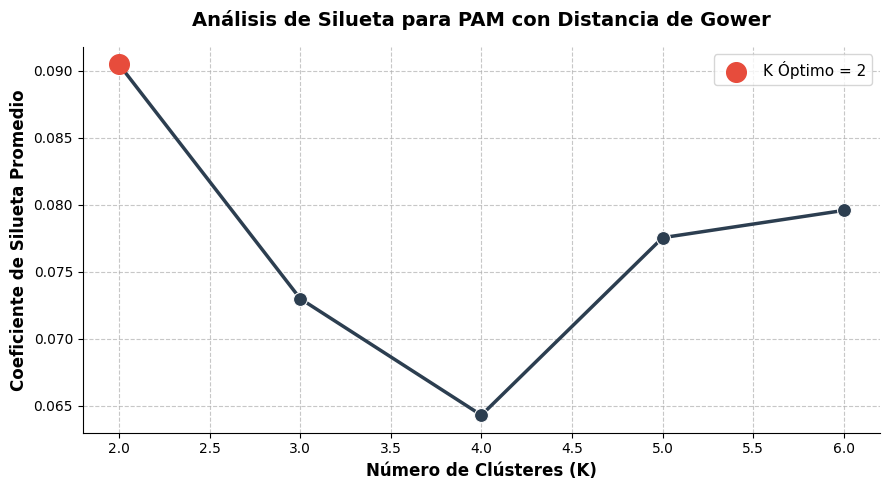

In [ ]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("EVALUACIÓN DEL NÚMERO ÓPTIMO DE CLÚSTERES (K)")
print("=" * 60)

# Rango de clústeres a evaluar
rango_k = range(2, 7)
valores_silueta = []

print("Calculando el Coeficiente de Silueta para distintos valores de K...")

for k in rango_k:
    # Instanciamos el modelo PAM (K-Medoids)
    # Es vital indicarle metric='precomputed' para que no intente calcular distancias Euclidianas,
    # sino que entienda que le estamos pasando una matriz de distancias lista.
    pam = KMedoids(n_clusters=k, metric='precomputed', method='pam', init='heuristic', random_state=42)
    
    # Ajustamos el modelo pasando nuestra matriz de Gower
    etiquetas_k = pam.fit_predict(matriz_distancias)
    
    # Calculamos el promedio de la silueta utilizando también la matriz precomputada
    silueta_promedio = silhouette_score(matriz_distancias, etiquetas_k, metric='precomputed')
    valores_silueta.append(silueta_promedio)
    
    print(f" -> Para K={k}, el Coeficiente de Silueta es: {silueta_promedio:.4f}")

# Visualización de los resultados
plt.figure(figsize=(9, 5))
sns.lineplot(x=list(rango_k), y=valores_silueta, marker='o', color='#2c3e50', linewidth=2.5, markersize=10)

# Resaltamos el punto máximo
k_optimo = rango_k[np.argmax(valores_silueta)]
max_silueta = max(valores_silueta)
plt.scatter(k_optimo, max_silueta, color='#e74c3c', s=200, zorder=5, label=f'K Óptimo = {k_optimo}')

plt.title('Análisis de Silueta para PAM con Distancia de Gower', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Clústeres (K)', fontsize=12, fontweight='bold')
plt.ylabel('Coeficiente de Silueta Promedio', fontsize=12, fontweight='bold')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación**: Los resultados del Coeficiente de Silueta nos ofrecen una muestran un gráfico de la naturaleza de los datos financieros. Observamos que el valor máximo se alcanza en $K=2$ con un coeficiente de 0.0905, seguido de un repunte en $K=5$ y $K=6$.

Desde una perspectiva estrictamente matemática, los valores de la silueta (entre el 0.06 - 0.09) son bajos si los comparamos con datasets de prueba artificiales (donde se esperan valores $>0.5$). Un coeficiente cercano a cero indica que los clústeres son densos pero sus fronteras están superpuestas. Esto es un comportamiento normal y esperado en el el contexto de este dataset. Recordemos que el comportamiento de endeudamiento humano tiene factores estocásticos. No existe una frontera definida para los distintos perfiles; más aún, cuando se toman en consideración múltiples características (9 en partícular).

De acuerdo a nuestro resultado, tomaremos $K=2$ como nuestro número óptimo de clústeres. Esto significa que nuestra cartera vencida se divide en dos grandes macro-perfiles de incumplimiento. Para fines prácticos de este proyecto, manejar dos perfiles altamente distintos parece una decisión adecuado y mucho más manejable que intentar perfilar seis agrupaciones con fronteras difusas.

# 5. Entrenamiento y Visualización Dimensional
Con el número óptimo de clústeres definido ($K=2$), procederemos a la fase de particionamiento definitivo y a la representación gráfica de nuestros hallazgos, cumpliendo con el objetivo de hacer que el modelo sea interpretable visualmente.

## 5.1. Ejecución del Algoritmo PAM
Instanciaremos nuestro modelo *K-Medoids* configurado para encontrar 2 clústeres, alimentándolo nuevamente con nuestra matriz de distancias de Gower precomputada. Al finalizar el ajuste, el algoritmo asignará a cada uno de los 10,000 créditos de la muestra una etiqueta (Clúster 0 o Clúster 1). 

Una de las grandes ventajas de este enfoque es que el modelo nos devolverá los índices exactos de los dos clientes que fungen como "Medoides" (los representantes centrales de cada grupo), los cuales utilizaremos más adelante para perfilar la cartera.

## 5.2. Proyección Dimensional (t-SNE)
Nuestro vector de características actual tiene 9 dimensiones, lo cual es inviable de graficar y comprender visualmente. Necesitamos reducir esta dimensionalidad a un plano 2D (Eje X y Eje Y).

Aunque el Análisis de Componentes Principales (PCA) es la técnica más común para este propósito, PCA asume relaciones lineales y requiere que los datos sean numéricos y continuos, lo cual invalida su uso directo sobre nuestras variables categóricas. 

En su lugar, utilizaremos **t-SNE** (T-distributed Stochastic Neighbor Embedding). Esta es una técnica avanzada de reducción de dimensionalidad no lineal. La ventaja fundamental de t-SNE para nuestro proyecto es que **acepta matrices de distancias precomputadas**. Es decir, le pasaremos directamente nuestra matriz de Gower, y t-SNE se encargará de proyectar esos 10,000 puntos en un plano bidimensional, intentando preservar fielmente las distancias locales relativas que calculamos. De este modo, si dos clientes tienen una distancia de Gower cercana a cero, t-SNE los dibujará juntos en el gráfico.

1. ENTRENAMIENTO DEL MODELO PAM (K=2)
[ÉXITO] Clústeres asignados. Los medoides representativos son los índices: [4103 9480]

2. REDUCCIÓN DE DIMENSIONALIDAD (t-SNE)
Proyectando la matriz a 2 dimensiones (Esto tomará unos momentos)...
[ÉXITO] Proyección bidimensional completada.

3. VISUALIZACIÓN DE LOS PERFILES DE MOROSIDAD


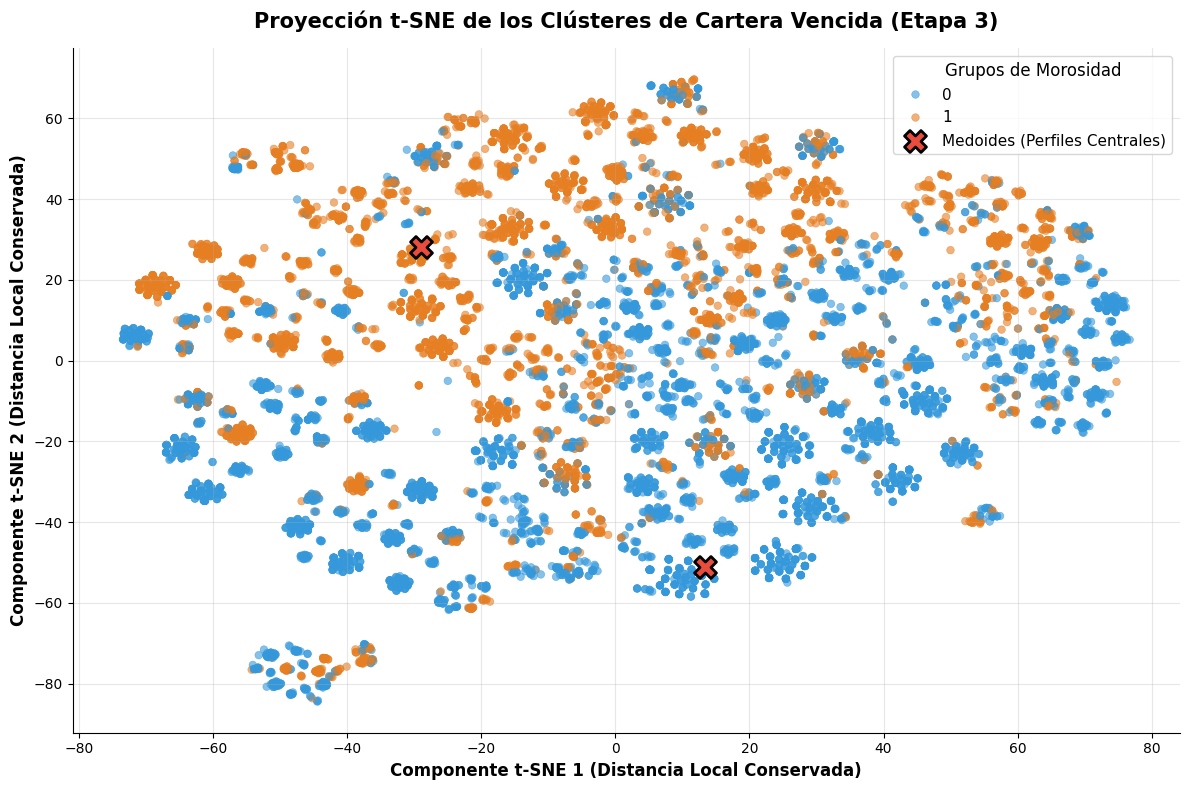

In [5]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("1. ENTRENAMIENTO DEL MODELO PAM (K=2)")
print("=" * 60)

# Definimos el K óptimo descubierto en el paso anterior
K_OPTIMO = 2

# Instanciamos y entrenamos el modelo definitivo
modelo_pam_final = KMedoids(n_clusters=K_OPTIMO, metric='precomputed', method='pam', init='heuristic', random_state=42)
etiquetas_cluster = modelo_pam_final.fit_predict(matriz_distancias)

# Agregamos las etiquetas al DataFrame original de la muestra
df_muestra_cluster['Cluster_Asignado'] = etiquetas_cluster

# Obtenemos los índices de los clientes que representan el centro exacto de cada clúster
indices_medoides = modelo_pam_final.medoid_indices_
print(f"[ÉXITO] Clústeres asignados. Los medoides representativos son los índices: {indices_medoides}\n")

print("=" * 60)
print("2. REDUCCIÓN DE DIMENSIONALIDAD (t-SNE)")
print("=" * 60)

# Configuramos t-SNE para que acepte nuestra matriz de Gower precomputada
# perplexity=50 es un valor robusto para tamaños de muestra de 10,000
tsne = TSNE(n_components=2, metric='precomputed', perplexity=50, init='random', random_state=42)

print("Proyectando la matriz a 2 dimensiones (Esto tomará unos momentos)...")
proyeccion_2d = tsne.fit_transform(matriz_distancias)

# Agregamos las coordenadas al DataFrame para graficarlas fácilmente
df_muestra_cluster['tSNE_1'] = proyeccion_2d[:, 0]
df_muestra_cluster['tSNE_2'] = proyeccion_2d[:, 1]

print("[ÉXITO] Proyección bidimensional completada.\n")

print("=" * 60)
print("3. VISUALIZACIÓN DE LOS PERFILES DE MOROSIDAD")
print("=" * 60)

plt.figure(figsize=(12, 8))

# Graficamos todos los puntos coloreados por su clúster
sns.scatterplot(
    x='tSNE_1', 
    y='tSNE_2', 
    hue='Cluster_Asignado', 
    palette=['#3498db', '#e67e22'], # Azul y Naranja
    data=df_muestra_cluster,
    alpha=0.6,
    s=30,
    edgecolor=None
)

# Resaltamos los medoides (centros) en la gráfica
# Extraemos las coordenadas t-SNE de los índices que el modelo identificó como medoides
coords_medoides = df_muestra_cluster.iloc[indices_medoides][['tSNE_1', 'tSNE_2']].values

plt.scatter(
    coords_medoides[:, 0], 
    coords_medoides[:, 1], 
    color='#e74c3c', # Rojo fuerte
    marker='X', 
    s=250, 
    edgecolor='black',
    linewidth=2,
    label='Medoides (Perfiles Centrales)',
    zorder=10
)

plt.title('Proyección t-SNE de los Clústeres de Cartera Vencida (Etapa 3)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Componente t-SNE 1 (Distancia Local Conservada)', fontsize=12, fontweight='bold')
plt.ylabel('Componente t-SNE 2 (Distancia Local Conservada)', fontsize=12, fontweight='bold')
plt.legend(title='Grupos de Morosidad', fontsize=11, title_fontsize=12, loc='best')
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

Lo que esta visualización nos confirma de la separación espacial. Podemos ver nubes de puntos (azul y naranja) que el algoritmo logró separar. Como era de esperarse en el modelado reducido a dos componentes (no interpretables), hay una frontera difusa donde los puntos se mezclan, sin embargo se destaca que los medoides están posicionados en un centro visual de densidad de cada grupo, confirmando a primera vista que con el algoritmo PAM, estos centros no fue arrastrados por valores atípicos.

# 6. Interpretación y Visualización de los Perfiles de Riesgo
La proyección t-SNE nos confirmó matemáticamente que existen dos grupos separados en nuestra cartera vencida. Sin embargo, para que este hallazgo tenga valor, se debemos traducir estos clústeres abstractos a perfiles humanos reales.

Para lograrlo, cruzaremos las etiquetas que el modelo PAM asignó a cada crédito (`Cluster_Asignado`) con las variables crudas y originales de nuestro conjunto de datos. 

## 6.1. Visualización de perfiles: Dispersión Cruzada
Comenzaremos analizando la relación entre las dos variables demográficas más importantes: el `intervalo_edades` y el `intervalo_ingreso_acreditado`. 

Dado que ambas son variables ordinales discretas, intentar visualizarlas en un gráfico de dispersión tradicional provocaría un problema de superposición absoluta (*overplotting*): los 10,000 puntos colapsarían en unas cuantas coordenadas exactas de la cuadrícula, impidiendo ver la densidad de los clústeres.

Para revelar la distribución real, utilizaremos un **Gráfico de Dispersión con Jitter** (*Stripplot*). Esta técnica inyecta una cantidad calculada de ruido estocástico (desplazamiento aleatorio microscópico) a las coordenadas de cada punto. Esto no altera el valor real de la variable, pero hace que los puntos "vibren" alrededor de su coordenada, formando "enjambres" que nos permiten apreciar el volumen de personas, la densidad de los grupos y cómo se distribuye el riesgo a lo largo de las distintas etapas de la vida y niveles de ingreso.

RADIOGRAFÍA DEMOGRÁFICA: EDAD VS INGRESO POR CLÚSTER


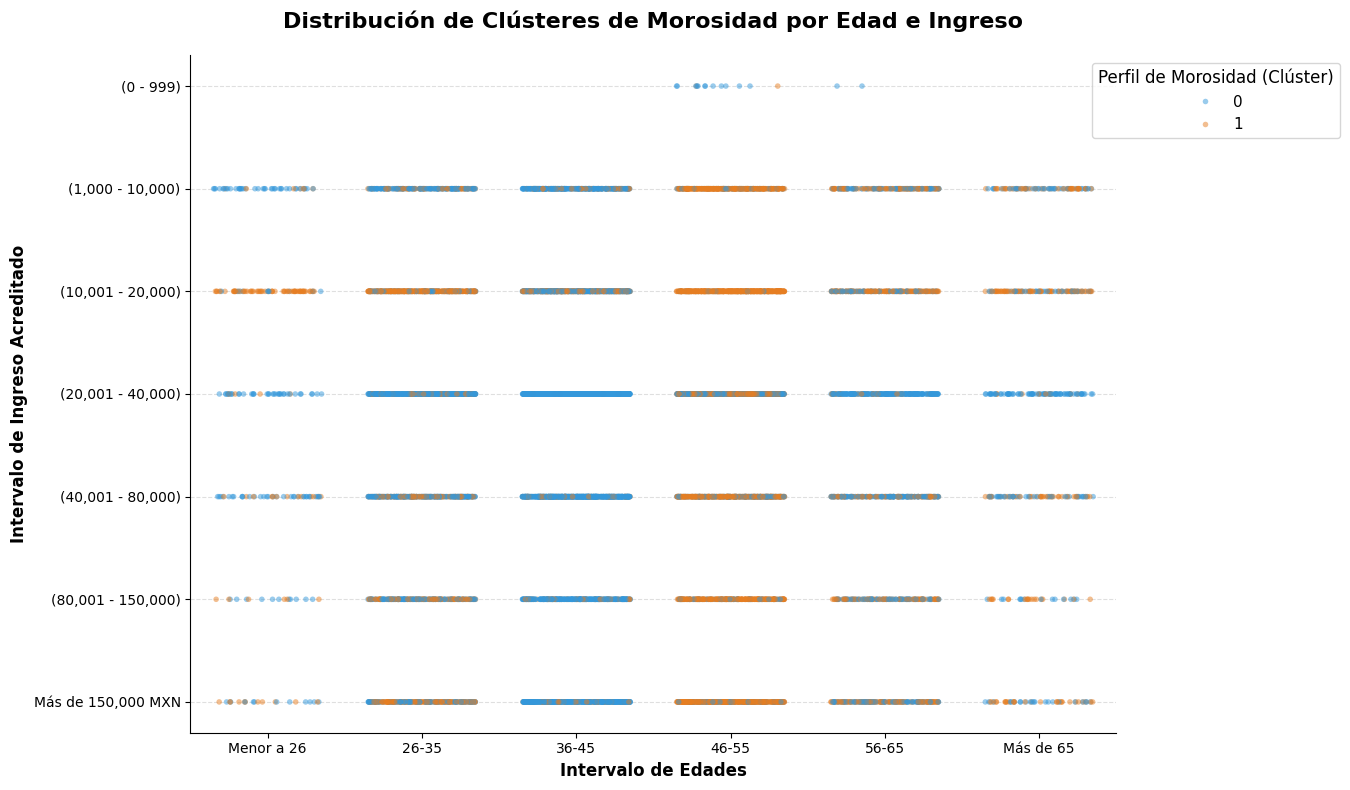

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("RADIOGRAFÍA DEMOGRÁFICA: EDAD VS INGRESO POR CLÚSTER")
print("=" * 60)

# Definimos el orden lógico cronológico para las edades (para que el eje X tenga sentido temporal)
orden_edades = ['Menor a 26', '26-35', '36-45', '46-55', '56-65', 'Más de 65']

plt.figure(figsize=(14, 8))

# Generamos el Stripplot (Dispersión con Jitter)
sns.stripplot(
    data=df_muestra_cluster, 
    x='intervalo_edades', 
    y='intervalo_ingreso_acreditado', 
    hue='Cluster_Asignado',
    palette=['#3498db', '#e67e22'], # Azul y Naranja para mantener la consistencia
    order=orden_edades,
    jitter=0.35, # Nivel de dispersión horizontal
    alpha=0.5,   # Transparencia para ver zonas de alta densidad
    s=4        # Tamaño de los puntos
)

plt.title('Distribución de Clústeres de Morosidad por Edad e Ingreso', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Intervalo de Edades', fontsize=12, fontweight='bold')
plt.ylabel('Intervalo de Ingreso Acreditado', fontsize=12, fontweight='bold')

# Ajustamos la leyenda
plt.legend(title='Perfil de Morosidad (Clúster)', fontsize=11, title_fontsize=12, loc='upper right', bbox_to_anchor=(1.25, 1))

plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación**: Aunque el Stripplot cumple su función de mostrarnos que hay 10,000 observaciones ahí (y no solo 30 puntos apilados), visualmente sigue siendo poco interpretable. Sin embargo, si observamos de manera con cuidado podemos ver que los colores de cada clúster pueden agruparse en ciertas partes de la cuadricula, dandonos una idea inicial de los perfiles:
* La Nube Azul (Clúster 0), se concentra fuertemente en el un vector de y "36-45" años, con ingresos que van desde "20,001 - 40,000" hasta "Más de 150,000".
* La Nube Naranja (Clúster 1), empieza a dominar conforme nos movemos hacia la derecha y hacia arriba. En particular para el sector de "46-55" y "56-65" años con ingresos de "1,000 - 10,000" y "10,001 y 20,000".

Para eliminar esta ambigüedad visual y convertir esta gráfica en algo más interpretable, pasaremos a otra herramienta estadística más útil para conteos categóricos: el Gráfico de Barras Agrupadas.

## 6.2. Visualización de perfiles: Gráficos de Barras Agrupadas
Aunque el gráfico de dispersión estocástica nos permitió intuir ciertas concentraciones, la toma de decisiones exige más precisión. Sabiendo que esta herramienta será la más interpretable, extenderemos su uso a todas las variables catégoricas.

Para cuantificar exactamente cómo se distribuye la morosidad y perfilar de manera más acertada a nuestros dos grupos, desglosaremos las seis variables cualitativas principales de nuestro análisis, utilizando gráficos de barras agrupadas (*Countplots*). Esta visualización contará el número exacto de créditos vencidos que pertenecen a cada clúster según la dimensión demográfica (edad, ingreso, sector laboral) y la dimensión del producto (estado, destino del crédito, segmento de vivienda)., revelándonos de manera más explícita las fronteras demográficas de cada perfil.

CUANTIFICACIÓN INTEGRAL: DEMOGRAFÍA Y PRODUCTO
Generando panel de visualización...


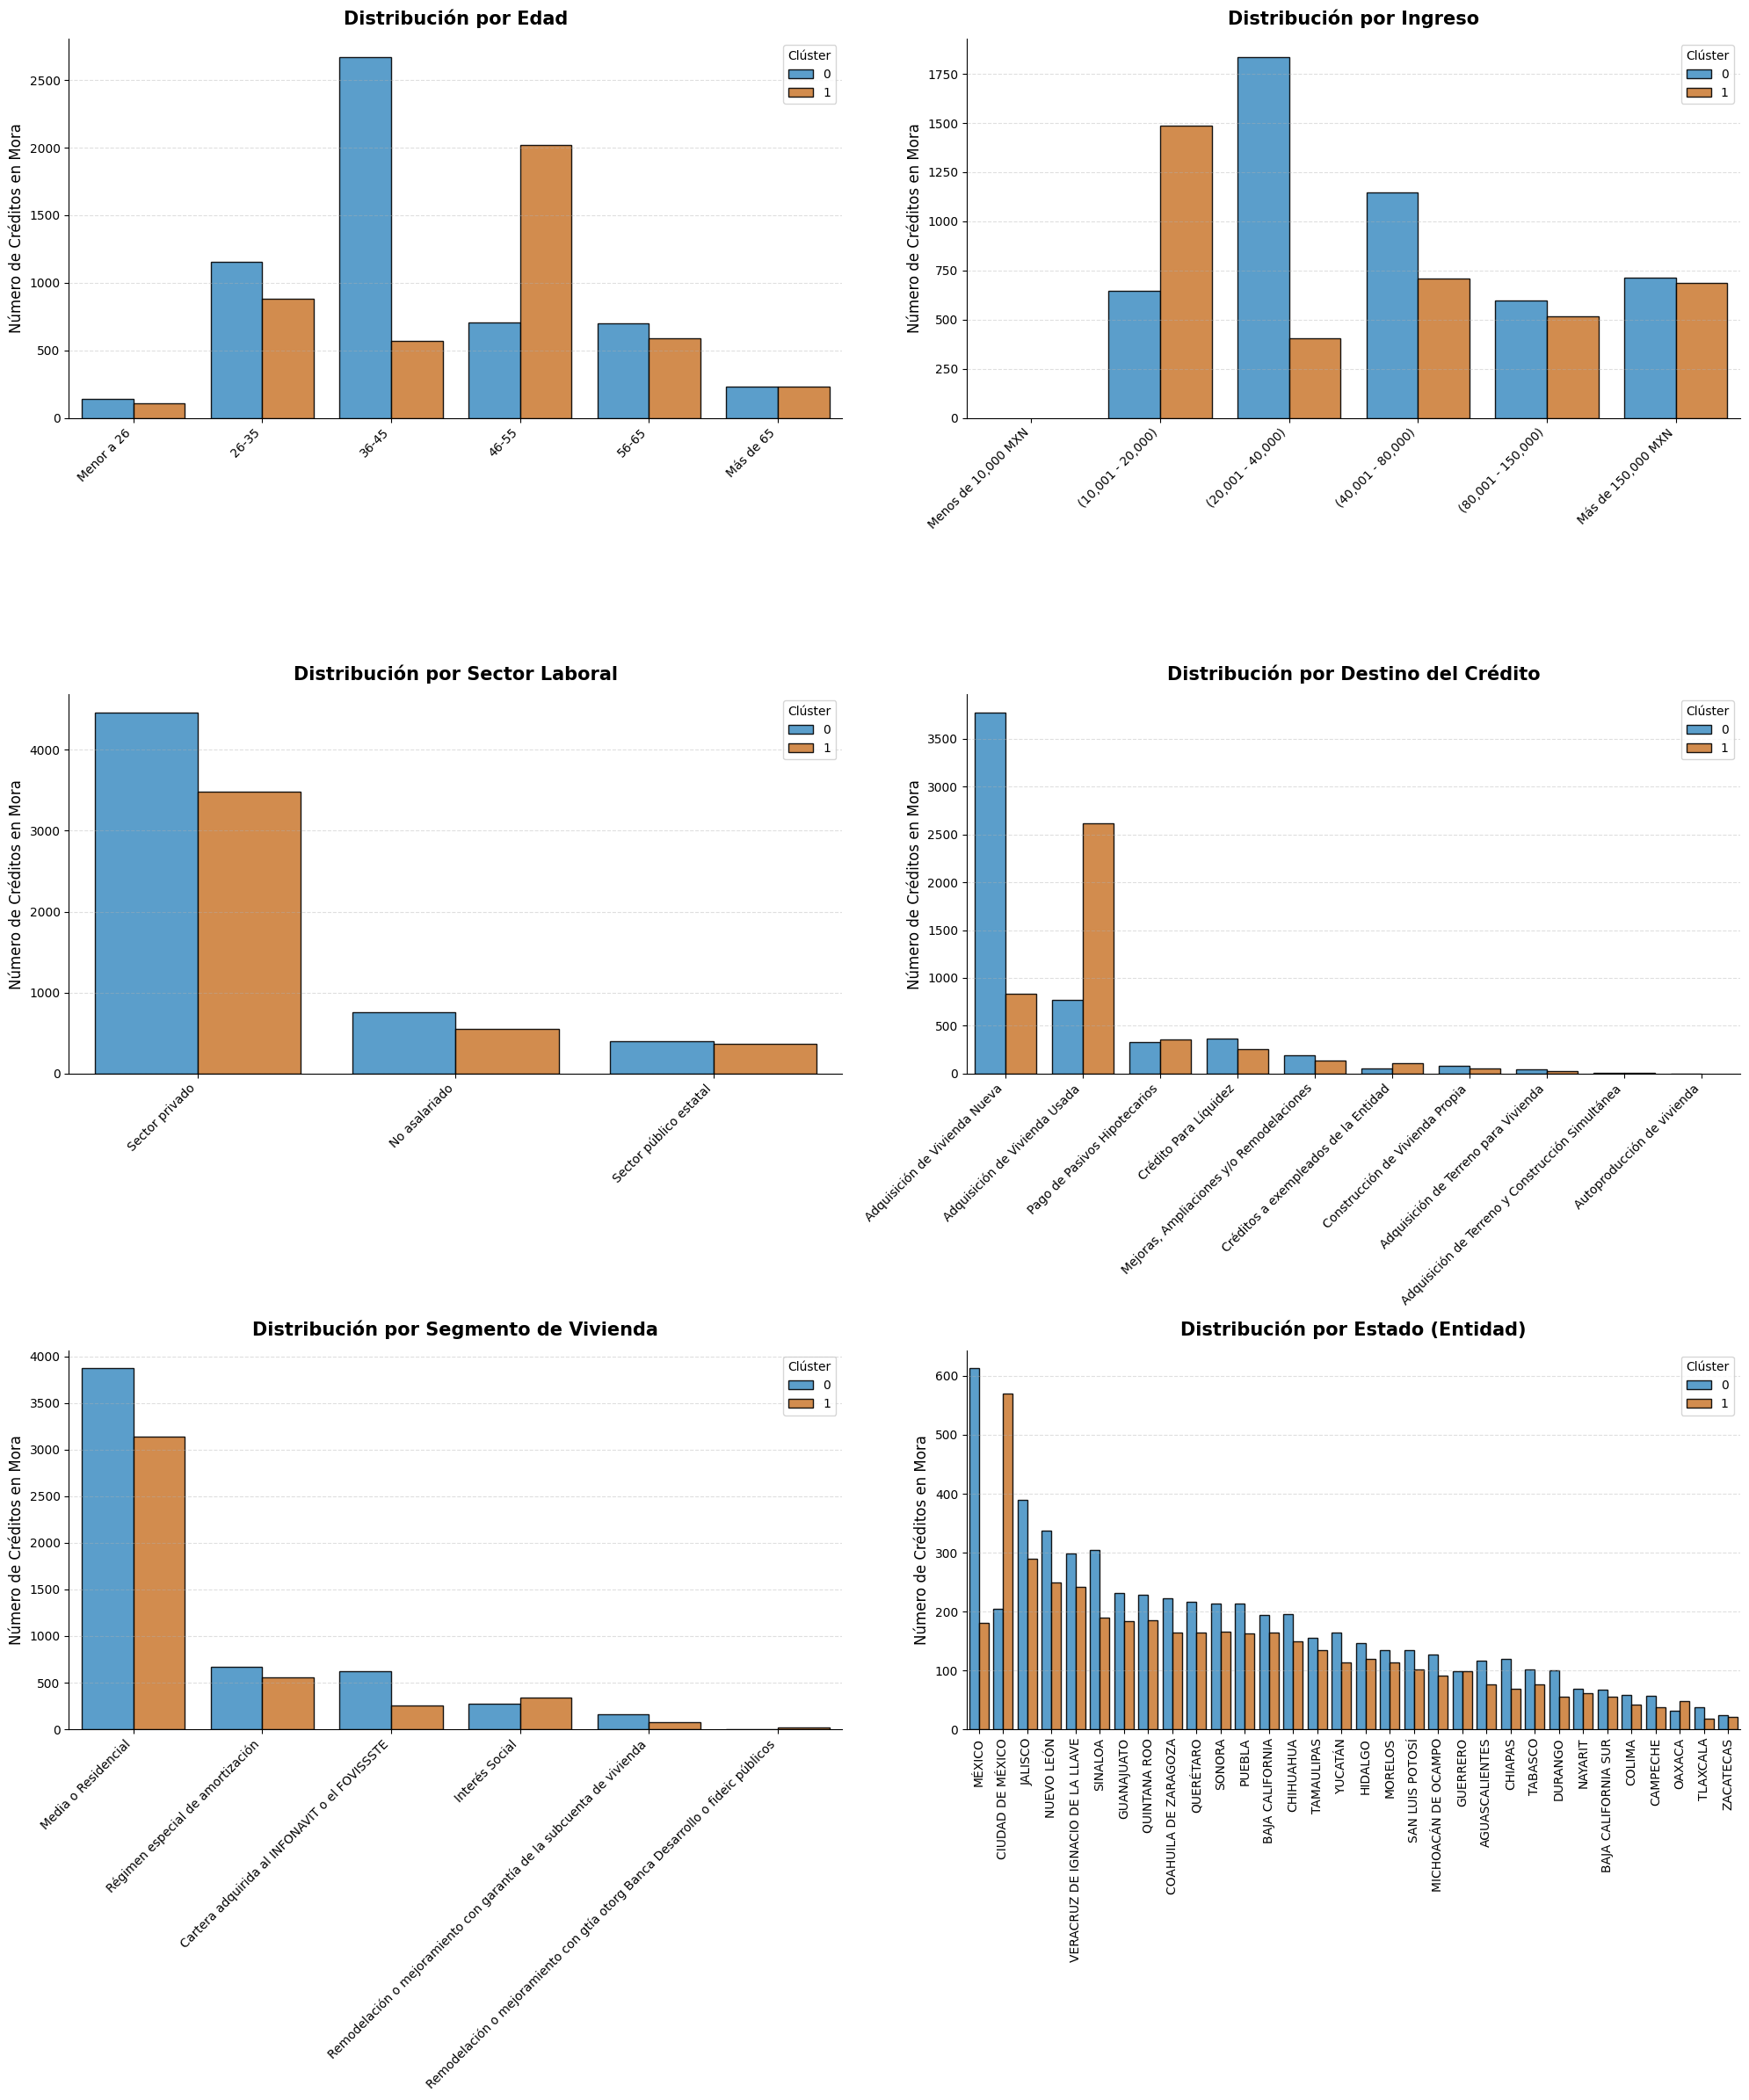

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("CUANTIFICACIÓN INTEGRAL: DEMOGRAFÍA Y PRODUCTO")
print("=" * 60)

# 1. Definimos el orden cronológico/jerárquico para las variables ordinales
orden_edades = ['Menor a 26', '26-35', '36-45', '46-55', '56-65', 'Más de 65']
orden_ingresos = [
    'Menos de 10,000 MXN', '(10,001 - 20,000)', '(20,001 - 40,000)', 
    '(40,001 - 80,000)', '(80,001 - 150,000)', 'Más de 150,000 MXN'
]

# 2. Preparamos la cuadrícula de 3 filas x 2 columnas
fig, axes = plt.subplots(3, 2, figsize=(20, 24))
axes = axes.flatten() # Aplanamos la matriz de ejes para iterar fácilmente

# 3. Lista de configuración para cada variable: (columna, título, orden_personalizado)
variables_categoricas = [
    ('intervalo_edades', 'Distribución por Edad', orden_edades),
    ('intervalo_ingreso_acreditado', 'Distribución por Ingreso', orden_ingresos),
    ('sector_laboral', 'Distribución por Sector Laboral', None),
    ('destino_credito', 'Distribución por Destino del Crédito', None),
    ('segmento_vivienda', 'Distribución por Segmento de Vivienda', None),
    ('estado', 'Distribución por Estado (Entidad)', None)
]

print("Generando panel de visualización...")

# 4. Iteramos y graficamos
for i, (var, titulo, orden) in enumerate(variables_categoricas):
    # Si la variable es nominal (orden = None), ordenamos por frecuencia descendente
    if orden is None:
        orden = df_muestra_cluster[var].value_counts().index
        
    sns.countplot(
        data=df_muestra_cluster,
        x=var,
        hue='Cluster_Asignado',
        palette=['#3498db', '#e67e22'],
        order=orden,
        ax=axes[i],
        edgecolor='black',
        alpha=0.9
    )
    
    # Formato y estética de cada subgráfico
    axes[i].set_title(titulo, fontsize=15, fontweight='bold', pad=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Número de Créditos en Mora', fontsize=12)
    axes[i].legend(title='Clúster', loc='upper right', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)
    
    # Rotamos las etiquetas del eje X. Para 'estado' usamos 90 grados por la cantidad de categorías.
    rotacion = 90 if var == 'estado' else 45
    alineacion = 'center' if var == 'estado' else 'right'
    
    for tick in axes[i].get_xticklabels():
        tick.set_rotation(rotacion)
        tick.set_ha(alineacion)

sns.despine()
plt.tight_layout()
plt.show()

**Interpretación**: Nuestros gráficos de barras nos han permitido descartar variables de que causan ruido (como el Sector Laboral o el Segmento de Vivienda, dominados por las clases mayoritarias del portafolio del banco) y nos han revelado dos arquetipos preliminares de morosidad claramente diferenciados:

* **Perfil 0:** Acreditados relativamente jóvenes (36-45 años), con ingresos medios-altos ($20,000 - $40,000 MXN), que adquieren vivienda nueva predominantemente en la periferia en crecimiento (Estado de México). 
* **Perfil 1:** Acreditados maduros (46-55 años), con ingresos más bajos ($10,000 - $20,000 MXN), que adquieren vivienda usada en el núcleo urbano consolidado (Ciudad de México).

## 6.3. Revelación de Medoides

Para completar estos perfiles, nos falta analizar las (`saldo_insoluto_final_periodo` y `tasa_ponderada`) dimensiones financieras y revelar la identidad completa del coherte/clientes. Además, gracias a nuestra elección matemática del algoritmo PAM (K-Medoids), extraeremos de la base de datos los registros exactos de los dos clientes que fungen como el centroide real de cada grupo. Esto nos proporcionara el perfil completo de los cohertes morosos, permitiendo a las instituciones de crédito auditar casos concretos.

In [19]:
print("=" * 60)
print("AUDITORÍA DE NEGOCIO: LOS MEDOIDES (CLIENTES REALES)")
print("=" * 60)

# Extraemos las filas exactas de los clientes representativos usando los índices de PAM
medoides_df = df_muestra_cluster.iloc[indices_medoides].copy()

# Ordenamos las columnas para mostrar primero las demográficas y luego las financieras
columnas_medoides = [
    'Cluster_Asignado', 'intervalo_edades', 'intervalo_ingreso_acreditado', 
    'estado', 'destino_credito', 'saldo_insoluto_final_periodo', 'tasa_ponderada'
]

# Formateamos el saldo para que sea legible (con comas y decimales)
medoides_df['saldo_insoluto_final_periodo'] = medoides_df['saldo_insoluto_final_periodo'].apply(lambda x: f"${x:,.2f}")

display(medoides_df[columnas_medoides])

AUDITORÍA DE NEGOCIO: LOS MEDOIDES (CLIENTES REALES)


,Cluster_Asignado,intervalo_edades,intervalo_ingreso_acreditado,estado,destino_credito,saldo_insoluto_final_periodo,tasa_ponderada
402380,0,36-45,"(20,001 - 40,000)",MÉXICO,Adquisición de Vivienda Nueva,"$754,566.50",10.75
768867,1,46-55,"(10,001 - 20,000)",CIUDAD DE MÉXICO,Adquisición de Vivienda Usada,"$1,338,840.80",10.00


### Conclusión
El modelo no supervisado ha cumplido con el objetivo de enriquecer nuestro entendimiento de la cartera vencida. Mientras que nuestra Red Neuronal (modelo supervisado) actúa como un predictor para alertarnos quién tiene una alta probabilidad de caer en un perfil de riesgo crediticio alto, este modelo de clustering nos dota de las caracterísicas que tienen estos grupos morosos.
Al comprender que no todos los morosos son iguales, las instituciones pueden dejar de aplicar estrategias de cobranza genéricas y transicionar hacia soluciones focalizadas: por ejemplo pudiendo ofrecer reestructuraciones especificas para cada perfil, o implementar filtros más estrictos para futuros prospectos que comparten estos mismos arquetipos.